In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tensorflow MNIST Dataset info:
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)
Pixel value range: 0 to 255
Number of classes: 10


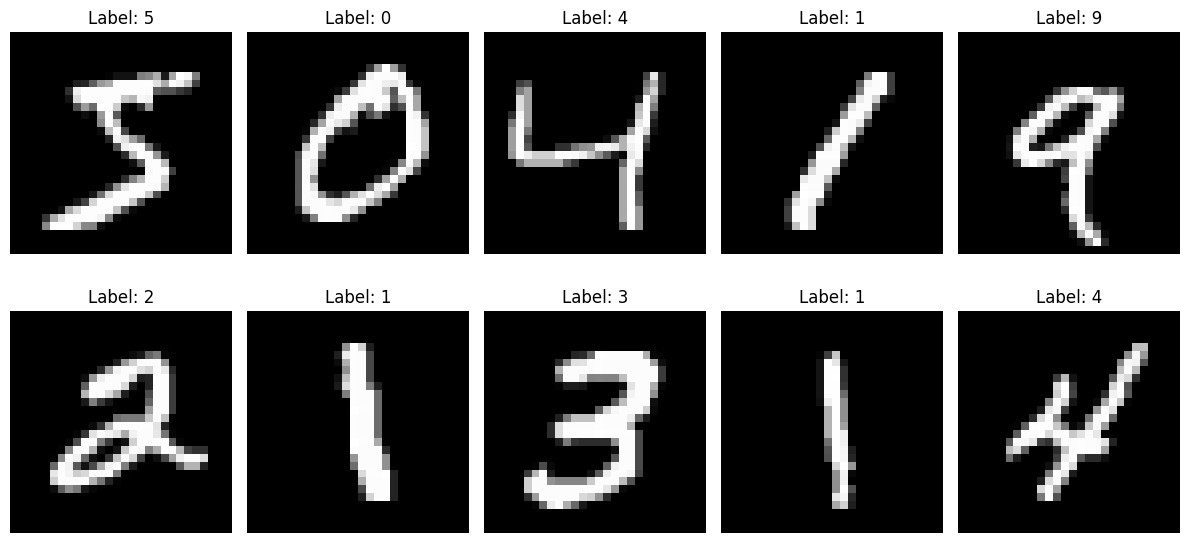

In [2]:
(x_train_tf,y_train_tf),(x_test_tf,y_test_tf)=keras.datasets.mnist.load_data()
print("Tensorflow MNIST Dataset info:")
print(f"Training data shape: {x_train_tf.shape}")
print(f"Training labels shape: {y_train_tf.shape}")
print(f"Testing data shape: {x_test_tf.shape}")
print(f"Testing labels shape: {y_test_tf.shape}")
print(f"Pixel value range: {x_train_tf.min()} to {x_train_tf.max()}")
print(f"Number of classes: {len(np.unique(y_train_tf))}")
fig,axes=plt.subplots(2,5,figsize=(12,6))
for i in range(10):
    ax=axes[i//5,i%5]
    ax.imshow(x_train_tf[i],cmap='gray')
    ax.set_title(f"Label: {y_train_tf[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

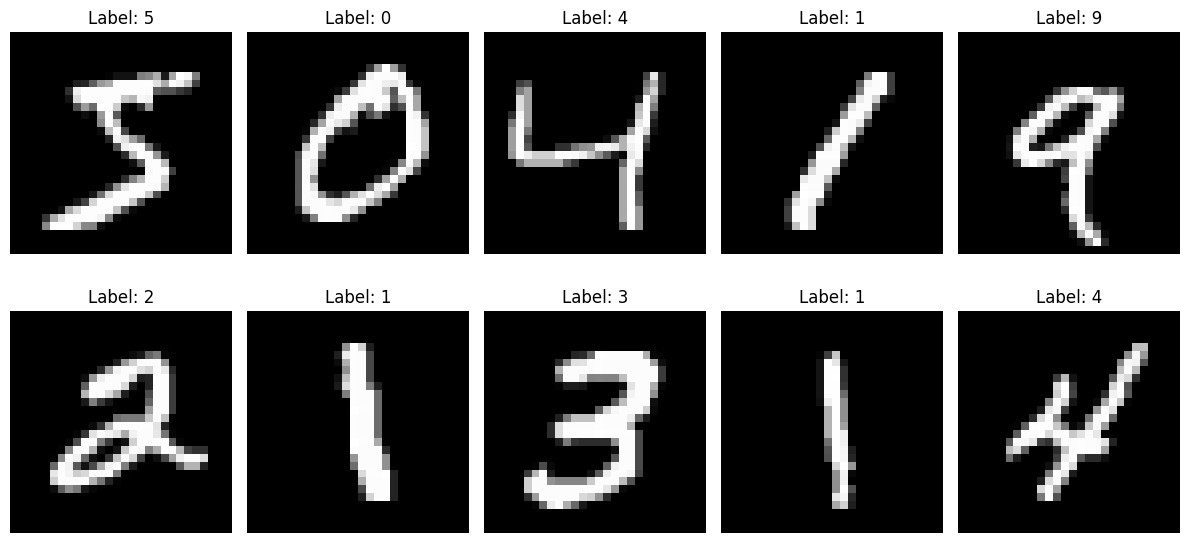

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(x_train_tf[i], cmap='gray')
    ax.set_title(f'Label: {y_train_tf[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
model_tf = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(28*28,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model_tf.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Tensorflow Model Summary:")
print(model_tf.summary())

Tensorflow Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
x_train_tf = x_train_tf / 255.0
x_test_tf = x_test_tf / 255.0

In [7]:
x_train_tf = x_train_tf.reshape(-1, 28*28)
x_test_tf = x_test_tf.reshape(-1, 28*28)

In [8]:
y_train_cat = tf.keras.utils.to_categorical(y_train_tf, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test_tf, 10)

print(f"✅ Data preprocessed!")
print(f"Training data shape: {x_train_tf.shape}")
print(f"Training labels shape: {y_train_cat.shape}")

✅ Data preprocessed!
Training data shape: (60000, 784)
Training labels shape: (60000, 10)


In [9]:
history = model_tf.fit(
    x_train_tf, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5726 - loss: 1.5622 - val_accuracy: 0.8777 - val_loss: 0.4508
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8833 - loss: 0.4134 - val_accuracy: 0.9107 - val_loss: 0.3080
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9167 - loss: 0.2884 - val_accuracy: 0.9356 - val_loss: 0.2218
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9350 - loss: 0.2251 - val_accuracy: 0.9501 - val_loss: 0.1775
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9499 - loss: 0.1714 - val_accuracy: 0.9558 - val_loss: 0.1531
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9580 - loss: 0.1393 - val_accuracy: 0.9618 - val_loss: 0.1328
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9655 - loss: 0.1165 - val_accuracy: 0.9606 - val_loss: 0.1306
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9686 - loss: 0.1045 

In [10]:
test_loss, test_acc = model_tf.evaluate(x_test_tf, y_test_cat)
print(f"\n✅ Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9663 - loss: 0.1130

✅ Test accuracy: 0.9704


In [11]:
predictions = model_tf.predict(x_test_tf[:10])
predicted_classes = np.argmax(predictions, axis=1)
print(f"\n🔍 First 10 predictions:")
print(f"Predicted: {predicted_classes}")
print(f"Actual:    {y_test_tf[:10]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

🔍 First 10 predictions:
Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


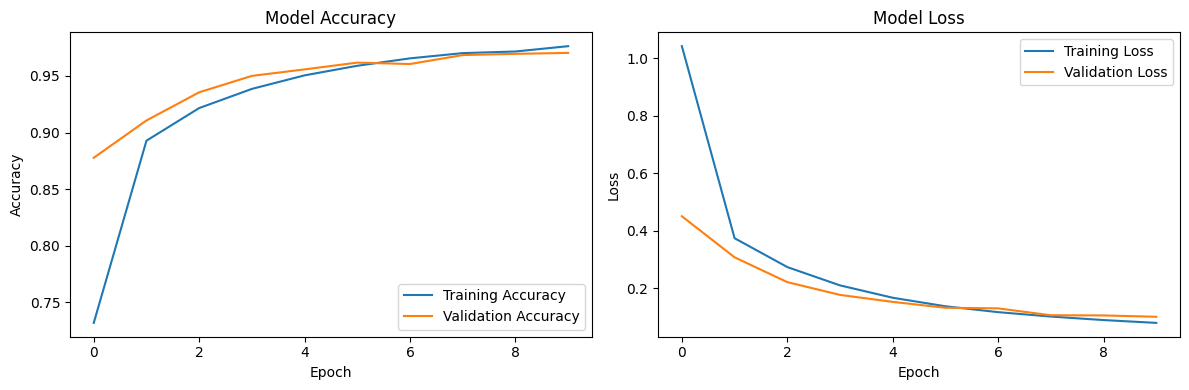

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

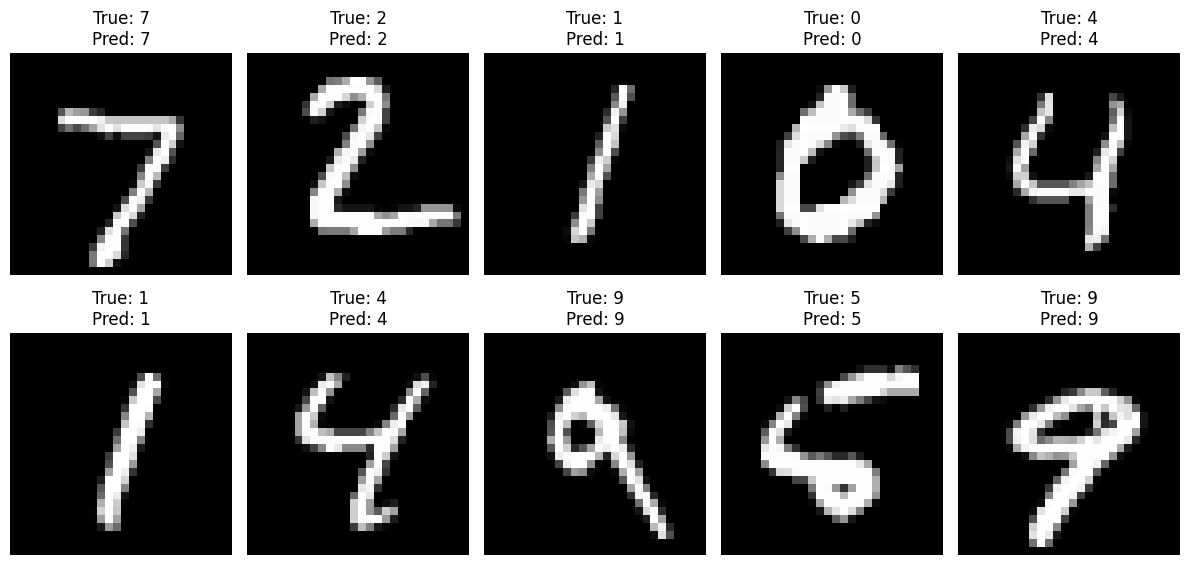

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    ax = axes[i//5, i%5]
    # Reshape back to 28x28 for display
    img = x_test_tf[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {y_test_tf[i]}\nPred: {predicted_classes[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()